## BigBasket Products - EDA Mini Project

## Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the BigBasket product dataset to understand product categories, pricing patterns, discounts, brands, and customer ratings. The analysis aims to identify key business insights and data quality issues.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
data = pd.read_csv("BigBasket Products.csv")


In [5]:
data.head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


In [6]:
data.describe()

,index,sale_price,market_price,rating
count,27555.00000,27549.000000,27555.000000,18919.000000
mean,13778.00000,334.648391,382.056664,3.943295
std,7954.58767,1202.102113,581.730717,0.739217
min,1.00000,2.450000,3.000000,1.000000
25%,6889.50000,95.000000,100.000000,3.700000
50%,13778.00000,190.320000,220.000000,4.100000
75%,20666.50000,359.000000,425.000000,4.300000
max,27555.00000,112475.000000,12500.000000,5.000000


In [7]:
data.shape

(27555, 10)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27549 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18919 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


In [9]:
data.isnull().sum()

index              0
product            1
category           0
sub_category       0
brand              1
sale_price         6
market_price       0
type               0
rating          8636
description      115
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(0)

## Data Cleaning

In [11]:
data["product"].fillna("Unknown", inplace = True)

In [12]:
data.isnull().sum()

index              0
product            0
category           0
sub_category       0
brand              1
sale_price         6
market_price       0
type               0
rating          8636
description      115
dtype: int64

In [13]:
data["brand"].fillna("Unknown" , inplace = True)

In [14]:
data.isnull().sum()

index              0
product            0
category           0
sub_category       0
brand              0
sale_price         6
market_price       0
type               0
rating          8636
description      115
dtype: int64

In [15]:
data["sale_price"].fillna(data["sale_price"].median() , inplace = True)

In [16]:
data.isnull().sum()

index              0
product            0
category           0
sub_category       0
brand              0
sale_price         0
market_price       0
type               0
rating          8636
description      115
dtype: int64

In [17]:
data["description"].fillna("No description", inplace = True)

In [18]:
data.isnull().sum()

index              0
product            0
category           0
sub_category       0
brand              0
sale_price         0
market_price       0
type               0
rating          8636
description        0
dtype: int64

In [19]:
# The rating column contained a large number of missing values, likely representing 
# products without customer reviews. Therefore, these values were retained as missing rather 
# than imputed.

## Exploratory Data Analysis

In [21]:
data["category"].nunique()

11

In [22]:
# Number of Products by Category

data["category"].value_counts()

category
Beauty & Hygiene            7867
Gourmet & World Food        4690
Kitchen, Garden & Pets      3580
Snacks & Branded Foods      2814
Foodgrains, Oil & Masala    2676
Cleaning & Household        2675
Beverages                    885
Bakery, Cakes & Dairy        851
Baby Care                    610
Fruits & Vegetables          557
Eggs, Meat & Fish            350
Name: count, dtype: int64

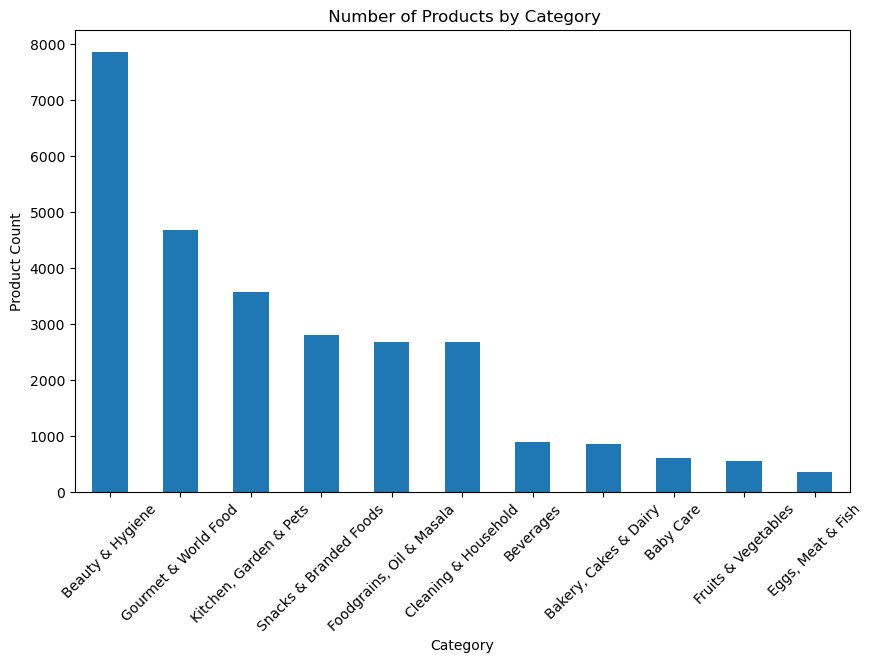

In [23]:
plt.figure(figsize = (10,6))

data["category"].value_counts().plot(kind = 'bar')
plt.title(' Number of Products by Category')
plt.xlabel('Category')
plt.ylabel ('Product Count')
plt.xticks(rotation = 45)

plt.show()

##### Observation- 

- Beauty & Hygiene has the highest number of products, while Eggs, Meat & Fish has the lowest product count.

In [24]:
# Top 10 Most Expensive Products

data[['product','sale_price']].sort_values(by='sale_price', ascending=False).head(10)

,product,sale_price
1249,Beard Kit,112475.00
248,4mm Aluminium Induction Base Chapati Roti Tawa...,111649.00
436,"Balloon - Polka Dot, 12 Inch",88899.00
288,Arrabbiata Tomato Pasta Sauce With Chilli,22325.00
25301,Bravura Clipper,12500.00
21761,Pet Food - N&D Team Breeder Puppy Top Farmina,10090.00
12669,Epilator SE9-9961 Legs-Body-Face,8184.44
23082,"Gas Stove-4 Burner Royale Plus Schott Glass, B...",7999.00
2781,Extra Virgin Olive Oil,7299.00
25797,"4 Burner Gas Stove - Marvel Plus Glass Tables,...",7270.00


## Observation -

- A small number of premium products contribute significantly to the upper end of the price distribution.

In [25]:
# Top brands analysis

data["brand"].value_counts().head(10)

brand
Fresho              638
bb Royal            539
BB Home             428
DP                  250
Fresho Signature    171
bb Combo            168
Amul                153
INATUR              146
Himalaya            141
Dabur               138
Name: count, dtype: int64

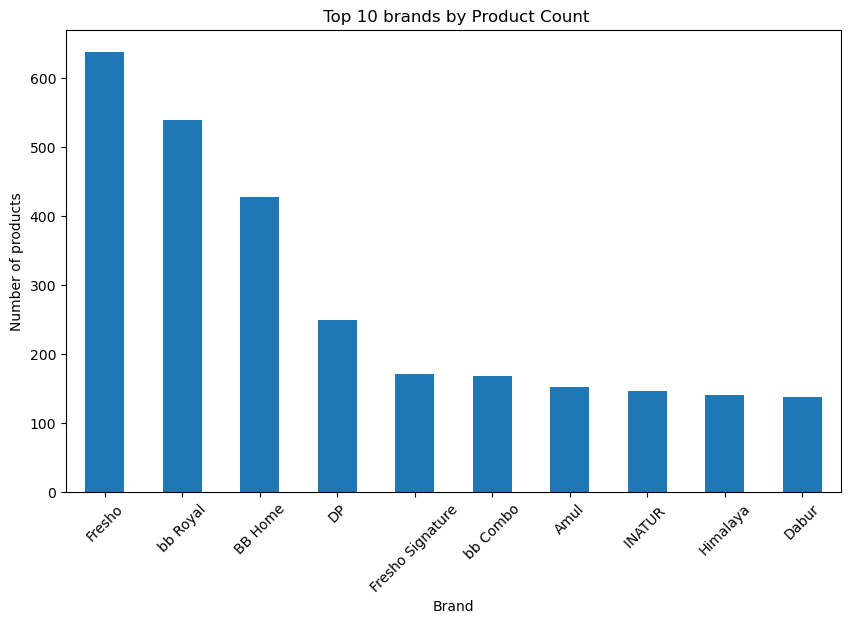

In [26]:
plt.figure(figsize = (10,6))

data["brand"].value_counts().head(10).plot(kind = 'bar')
plt.title(" Top 10 brands by Product Count")
plt.xlabel("Brand")
plt.ylabel("Number of products")
plt.xticks(rotation = 45)

plt.show()

##### Observation- 

- Fresho and bb Royal are the most represented brands in the dataset.

In [27]:
# Price analysis

data["sale_price"].describe()

count     27555.000000
mean        334.616964
std        1201.973111
min           2.450000
25%          95.000000
50%         190.320000
75%         359.000000
max      112475.000000
Name: sale_price, dtype: float64

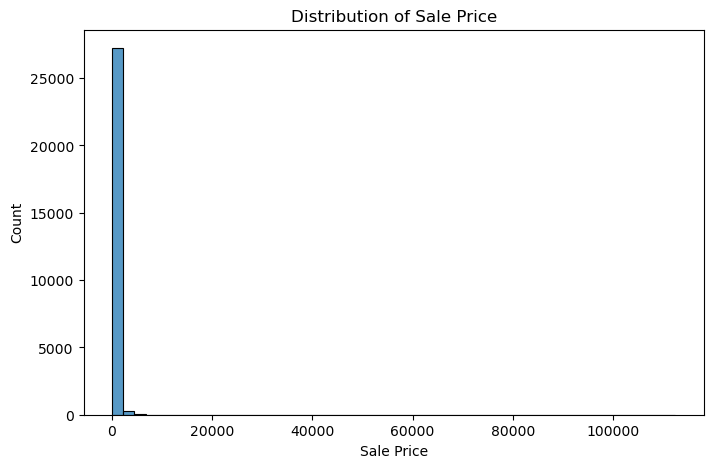

In [28]:
plt.figure(figsize = (8,5))

sns.histplot(data['sale_price'],bins = 50)

plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Count')

plt.show()

#### Observation-

- Most products belong to the lower price range, with a few premium-priced products creating outliers.

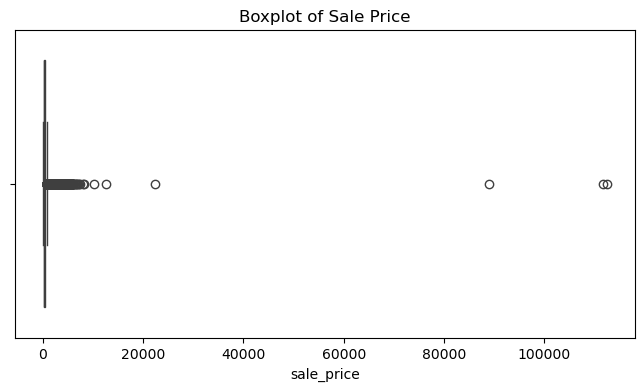

In [29]:
plt.figure(figsize = (8,4))

sns.boxplot(x= data['sale_price'])
plt.title('Boxplot of Sale Price')

plt.show()
          

#### Observation-

- Several high-price outliers are present in the dataset.

In [30]:
#Distribution of Discounts

data['discount'] = data['market_price']-data['sale_price']

data['discount'].describe()

count     27555.000000
mean         47.439700
std        1099.200461
min     -110360.000000
25%           0.000000
50%           6.000000
75%          51.000000
max        4320.000000
Name: discount, dtype: float64

In [31]:
data[data['discount'] < 0][['product','sale_price','market_price','discount']].head()

,product,sale_price,market_price,discount
248,4mm Aluminium Induction Base Chapati Roti Tawa...,111649.0,1289.0,-110360.0
288,Arrabbiata Tomato Pasta Sauce With Chilli,22325.0,325.0,-22000.0
412,Original Care Lip Balm For 24h Moisture With S...,1114.8,140.0,-974.8
436,"Balloon - Polka Dot, 12 Inch",88899.0,129.0,-88770.0
1249,Beard Kit,112475.0,3300.0,-109175.0


In [32]:
(data['discount']<0).sum()

np.int64(10)

In [33]:
data = data[data['discount'] >= 0]

In [34]:
(data['discount'] < 0).sum()

np.int64(0)

In [35]:
data['discount'].describe()

count    27545.000000
mean        59.506965
std        169.644853
min          0.000000
25%          0.000000
50%          6.000000
75%         51.000000
max       4320.000000
Name: discount, dtype: float64

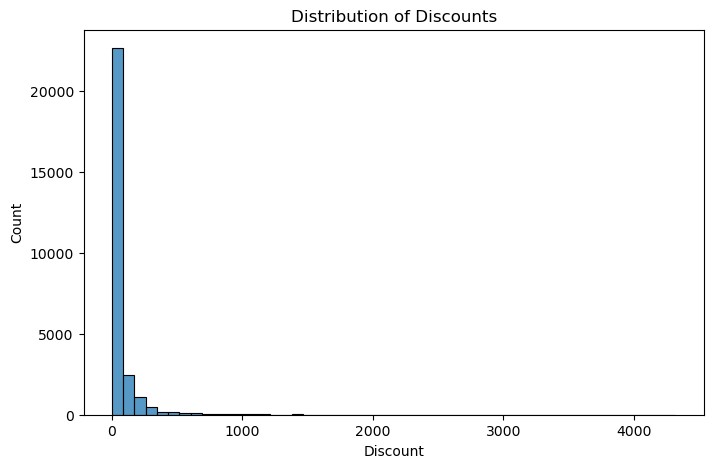

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(data['discount'], bins= 50)

plt.title('Distribution of Discounts')
plt.xlabel('Discount')
plt.ylabel('Count')

plt.show()

#### Observation - 

- Most products receive little or no discount, while only a few products receive high discounts

In [37]:
# Category-wise Average Discount

data.groupby('category')['discount'].mean().sort_values(ascending = False)

category
Kitchen, Garden & Pets      152.029055
Beauty & Hygiene             74.767041
Baby Care                    61.807918
Gourmet & World Food         38.575099
Foodgrains, Oil & Masala     36.978232
Eggs, Meat & Fish            36.938000
Cleaning & Household         35.968286
Beverages                    32.474949
Bakery, Cakes & Dairy        15.078566
Fruits & Vegetables          13.544327
Snacks & Branded Foods       11.186072
Name: discount, dtype: float64

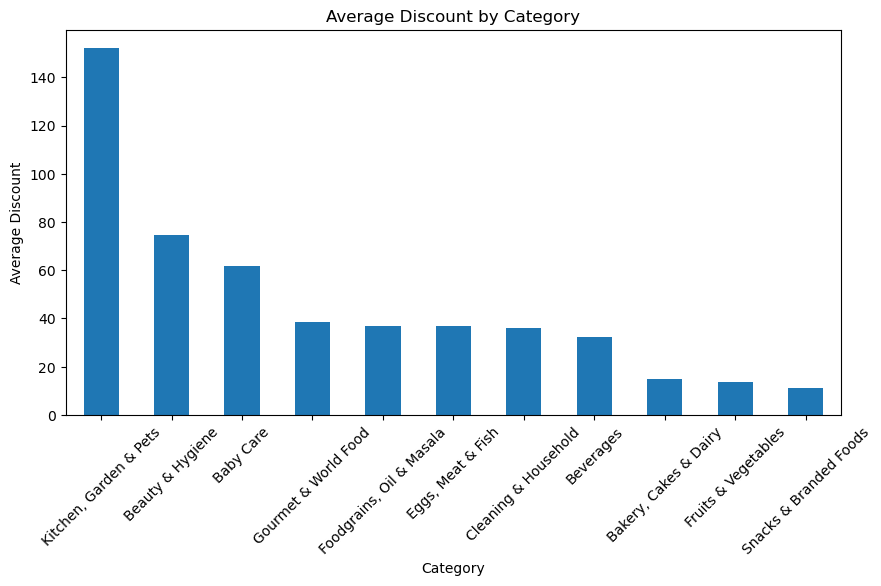

In [38]:
plt.figure(figsize=(10,5))

data.groupby('category')['discount'].mean()\
.sort_values(ascending=False)\
.plot(kind='bar')

plt.title('Average Discount by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount')

plt.xticks(rotation=45)
plt.show()

#### Observation -

- Kitchen, Garden & Pets has the highest average discount.

In [39]:
# Rating analysis


In [40]:
data['rating'].describe()

count    18913.000000
mean         3.943214
std          0.739289
min          1.000000
25%          3.700000
50%          4.100000
75%          4.300000
max          5.000000
Name: rating, dtype: float64

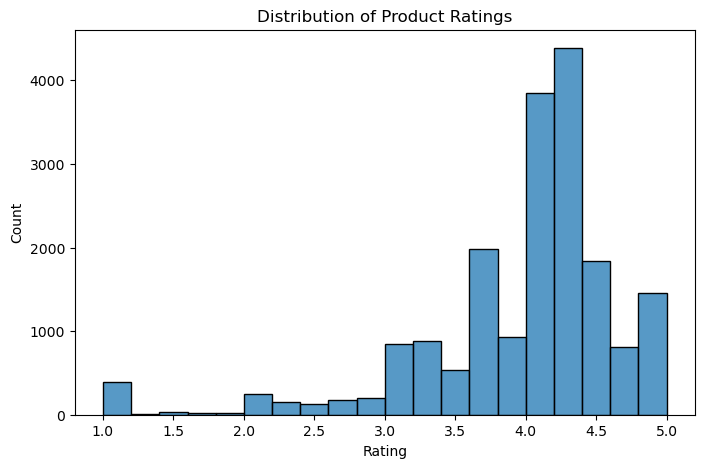

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(data['rating'], bins=20)

plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.show()

#### Observation -

- Most products have ratings between 3.5 and 4.5, indicating generally positive customer feedback.

In [42]:
# Category-wise rating

data.groupby('category')['rating'].mean().sort_values(ascending = False)

category
Beverages                   4.084858
Foodgrains, Oil & Masala    4.062181
Baby Care                   4.023790
Gourmet & World Food        3.983848
Snacks & Branded Foods      3.983009
Cleaning & Household        3.956536
Beauty & Hygiene            3.930416
Bakery, Cakes & Dairy       3.911128
Kitchen, Garden & Pets      3.734703
Eggs, Meat & Fish                NaN
Fruits & Vegetables              NaN
Name: rating, dtype: float64

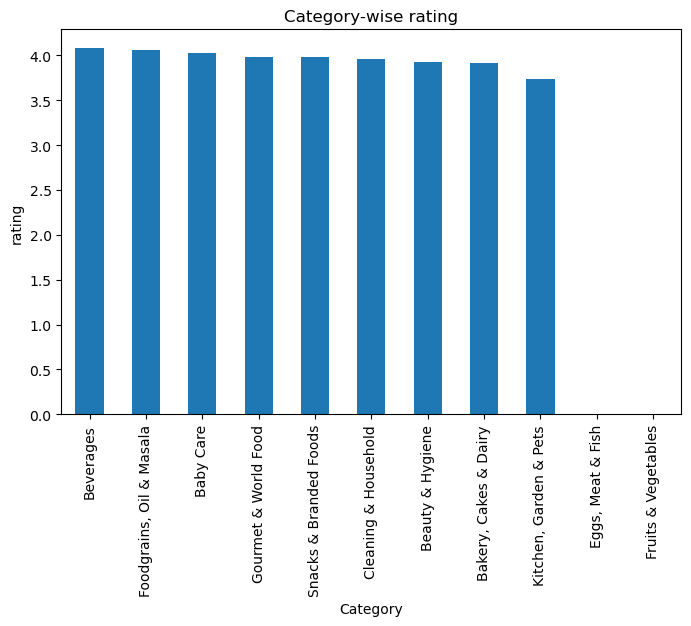

In [43]:

plt.figure(figsize = (8,5))

data.groupby('category')['rating'].mean().sort_values(ascending = False).plot(kind = 'bar')

plt.title('Category-wise rating')
plt.xlabel('Category')
plt.ylabel('rating')

plt.xticks(rotation=90)
plt.show()

#### Observation - 

- Beverages has the highest average rating, while Kitchen, Garden & Pets has the lowest.

## 1. Key Insights -

* Beauty & Hygiene is the largest product category in the dataset.
* Fresho is the most represented brand with the highest number of products.
* Product prices are highly right-skewed, with a few premium-priced products acting as outliers.
* Ten records with negative discounts were identified as pricing anomalies and removed from the analysis.
* Most products receive little or no discount, while only a few products receive high discounts.
* Kitchen, Garden & Pets has the highest average discount among all categories.
* Beverages has the highest average customer rating, indicating strong customer satisfaction.
* Kitchen, Garden & Pets has the lowest average rating among rated categories.


## 2. Recommendations - 

* Maintain strong inventory levels in high-performing categories such as Beauty & Hygiene.
* Review products in the Kitchen, Garden & Pets category to understand lower customer ratings.
* Continue promotional strategies in categories where discounts appear effective.
* Improve rating collection for categories with missing rating data, such as Fruits & Vegetables and Eggs, Meat & Fish.
* Regularly monitor pricing anomalies to ensure data quality and accurate business reporting.


## 3. Conclusion -

- This exploratory data analysis of the BigBasket product dataset provided insights into product categories, brands, pricing, discounts, 
and customer ratings. The analysis revealed that Beauty & Hygiene dominates the product catalog, while Beverages receives the highest customer 
ratings. Most products are sold with minimal discounts, although a few categories receive significantly higher promotional offers. Data quality
issues related to pricing anomalies were identified and resolved, ensuring more reliable analysis results.
